In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("telecom_churn.csv")

# Display the shape and first 5 rows
print("Shape:", df.shape)
print(df.head())

# Display column data types and missing values
print("\nData types and missing values:")
print(df.info())


Shape: (243553, 14)
   customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597             1/1/2020               4            124962          44   
1   125926             1/1/2020               2            130556          62   
2   423976             1/1/2020               0            148828          49   
3   522841             1/1/2020               1             38722          80   
4   740247             1/1/2020               2             55098          78   

   sms_sent  data_used  churn  
0        45     

In [3]:
# Drop ID, date, and label columns
df_clean = df.drop(['customer_id', 'pincode', 'date_of_registration', 'churn'], axis=1)

# Drop rows with missing values
df_clean = df_clean.dropna()

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_clean, columns=['telecom_partner', 'gender', 'state', 'city'], drop_first=True)

# Check shape and preview
print("New shape after encoding and cleaning:", df_encoded.shape)
print(df_encoded.head())


New shape after encoding and cleaning: (243553, 42)
   age  num_dependents  estimated_salary  calls_made  sms_sent  data_used  \
0   25               4            124962          44        45       -361   
1   55               2            130556          62        39       5973   
2   57               0            148828          49        24        193   
3   46               1             38722          80        25       9377   
4   26               2             55098          78        15       1393   

   telecom_partner_BSNL  telecom_partner_Reliance Jio  \
0                 False                          True   
1                 False                          True   
2                 False                         False   
3                  True                         False   
4                  True                         False   

   telecom_partner_Vodafone  gender_M  ...  state_Telangana  state_Tripura  \
0                     False     False  ...            False     

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the dataset
X_scaled = scaler.fit_transform(df_encoded)

# Print the shape to confirm
print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (243553, 42)


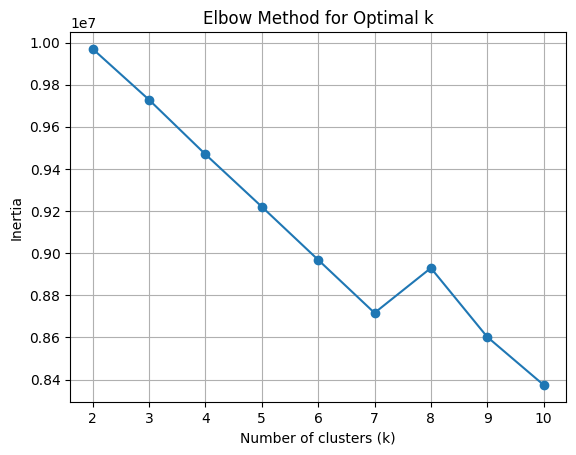

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
# Fit KMeans with optimal number of clusters
kmeans = KMeans(n_clusters=7, n_init=5, max_iter=100, random_state=42)
labels = kmeans.fit_predict(X_scaled)

X_sample, labels_sample = resample(X_scaled, labels, n_samples=10000, random_state=42)

# CALCULATE silhouette score
score = silhouette_score(X_sample, labels_sample)
print("Silhouette Score (sampled 10k):", score)


Silhouette Score (sampled 10k): 0.10993577428623864


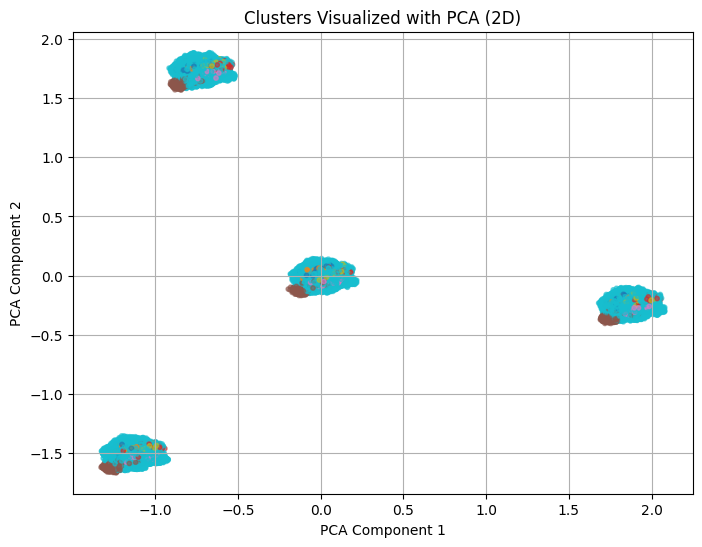

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10, alpha=0.6)
plt.title("Clusters Visualized with PCA (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()


In [8]:
import pandas as pd
df_clustered = pd.DataFrame(X_scaled, columns=df_encoded.columns)
df_clustered['cluster'] = labels

# View average values per cluster
cluster_summary = df_clustered.groupby('cluster').mean()
print(cluster_summary)


              age  num_dependents  estimated_salary  calls_made  sms_sent  \
cluster                                                                     
0       -0.006336       -0.004442         -0.011881   -0.015488 -0.004328   
1        0.010263        0.009194         -0.014775   -0.005396  0.005039   
2        0.008477       -0.009880          0.006936   -0.014221  0.000366   
3       -0.003022        0.009368         -0.012468   -0.002060  0.002859   
4        0.006731        0.007703         -0.027808    0.002355  0.009794   
5        0.000914       -0.003438          0.017860    0.009055 -0.016494   
6       -0.000772       -0.000388          0.001902    0.001169  0.000128   

         data_used  telecom_partner_BSNL  telecom_partner_Reliance Jio  \
cluster                                                                  
0         0.013283              0.005376                     -0.010955   
1         0.002339              0.011931                     -0.003474   
2         

In [9]:
# Reduce to 10 components with PCA
pca_10 = PCA(n_components=10)
X_pca_10 = pca_10.fit_transform(X_scaled)

# KMeans on PCA-reduced data
kmeans_pca = KMeans(n_clusters=7, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca_10)

# Silhouette score on reduced space
from sklearn.utils import resample
X_sample, labels_sample = resample(X_pca_10, labels_pca, n_samples=10000, random_state=42)
score_pca = silhouette_score(X_sample, labels_sample)
print("Silhouette Score after PCA (10D):", score_pca)


Silhouette Score after PCA (10D): 0.18272688411193588


In [10]:
import pandas as pd

# Original scaled data (with encoded column names)
df_clustered = pd.DataFrame(X_scaled, columns=df_encoded.columns)
df_clustered['cluster'] = labels_pca  # Use labels from PCA + KMeans

# Group by cluster and show mean feature values
cluster_profile = df_clustered.groupby('cluster').mean()

# Optional: round for readability
print(cluster_profile.round(2))


          age  num_dependents  estimated_salary  calls_made  sms_sent  \
cluster                                                                 
0       -0.00            0.00              0.01       -0.01      0.00   
1        0.00           -0.00              0.00        0.00      0.01   
2       -0.01            0.00             -0.00        0.00      0.00   
3        0.01           -0.00              0.00        0.00     -0.00   
4        0.00            0.01             -0.01        0.01     -0.00   
5       -0.00           -0.00              0.01       -0.01     -0.00   
6        0.00           -0.00             -0.00       -0.00     -0.00   

         data_used  telecom_partner_BSNL  telecom_partner_Reliance Jio  \
cluster                                                                  
0             0.01                 -0.58                         -0.58   
1            -0.00                 -0.00                         -0.01   
2            -0.01                 -0.58      

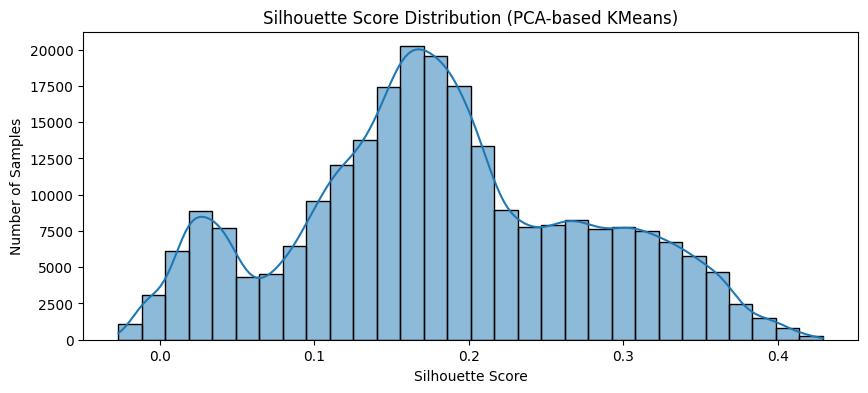

In [11]:
from sklearn.metrics import silhouette_samples
import seaborn as sns
import matplotlib.pyplot as plt

sample_scores = silhouette_samples(X_pca_10, labels_pca)

plt.figure(figsize=(10, 4))
sns.histplot(sample_scores, bins=30, kde=True)
plt.title("Silhouette Score Distribution (PCA-based KMeans)")
plt.xlabel("Silhouette Score")
plt.ylabel("Number of Samples")
plt.show()


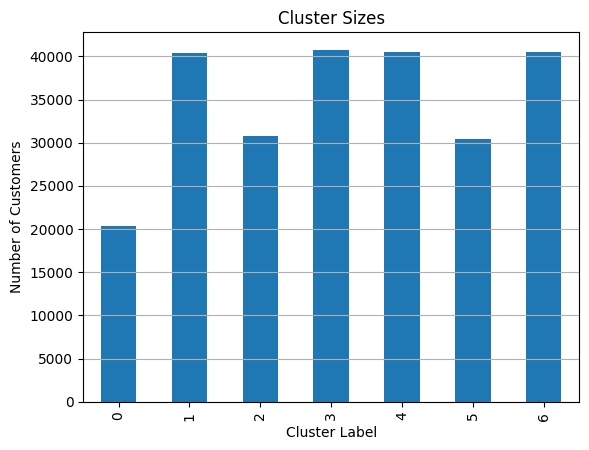

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Count of samples per cluster
pd.Series(labels_pca).value_counts().sort_index().plot(kind='bar')
plt.title("Cluster Sizes")
plt.xlabel("Cluster Label")
plt.ylabel("Number of Customers")
plt.grid(axis='y')
plt.show()


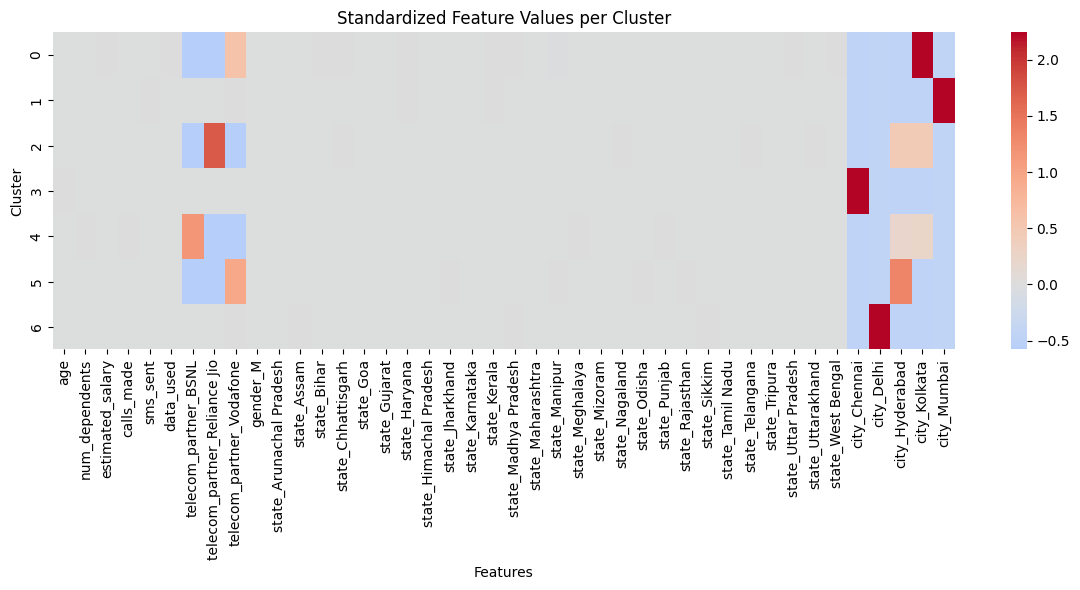

In [13]:
import seaborn as sns

# Use previously created cluster_summary (standardized values)
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile, cmap="coolwarm", center=0)
plt.title("Standardized Feature Values per Cluster")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [14]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X_pca_10, labels_pca)
print("Calinski-Harabasz Index:", ch_score)


Calinski-Harabasz Index: 29874.6565241581


In [15]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_pca_10, labels_pca)
print("Davies-Bouldin Index:", db_score)


Davies-Bouldin Index: 1.738066226741631


In [16]:
import numpy as np

# Display top 5 features per cluster
top_features = {}

for i in range(cluster_profile.shape[0]):
    cluster_vals = cluster_profile.iloc[i].abs().sort_values(ascending=False)[:5]
    top_features[i] = cluster_vals.index.tolist()

# Print to report or generate bar chart if needed
for i, features in top_features.items():
    print(f"Top features in Cluster {i}: {features}")


Top features in Cluster 0: ['city_Kolkata', 'telecom_partner_Vodafone', 'telecom_partner_Reliance Jio', 'telecom_partner_BSNL', 'city_Chennai']
Top features in Cluster 1: ['city_Mumbai', 'city_Chennai', 'city_Hyderabad', 'city_Kolkata', 'city_Delhi']
Top features in Cluster 2: ['telecom_partner_Reliance Jio', 'telecom_partner_Vodafone', 'telecom_partner_BSNL', 'city_Chennai', 'city_Delhi']
Top features in Cluster 3: ['city_Chennai', 'city_Hyderabad', 'city_Kolkata', 'city_Delhi', 'city_Mumbai']
Top features in Cluster 4: ['telecom_partner_BSNL', 'telecom_partner_Reliance Jio', 'telecom_partner_Vodafone', 'city_Chennai', 'city_Delhi']
Top features in Cluster 5: ['city_Hyderabad', 'telecom_partner_Vodafone', 'telecom_partner_Reliance Jio', 'telecom_partner_BSNL', 'city_Chennai']
Top features in Cluster 6: ['city_Delhi', 'city_Chennai', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai']


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi

# Combine original data with cluster labels
df_plot = df[['age', 'estimated_salary', 'data_used', 'calls_made', 'churn']].copy()
df_plot['cluster'] = labels_pca


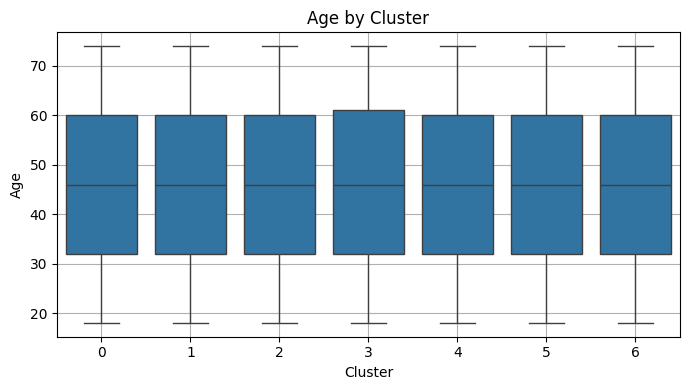

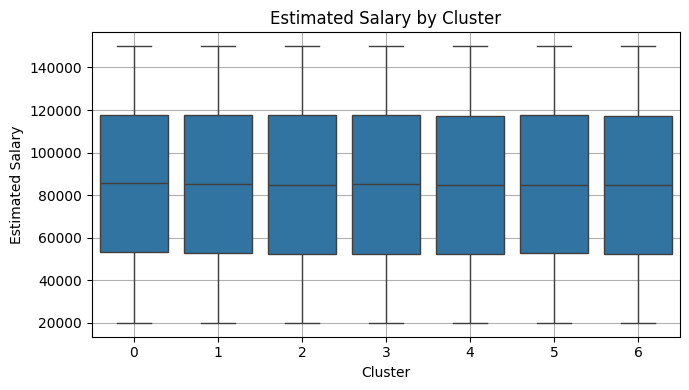

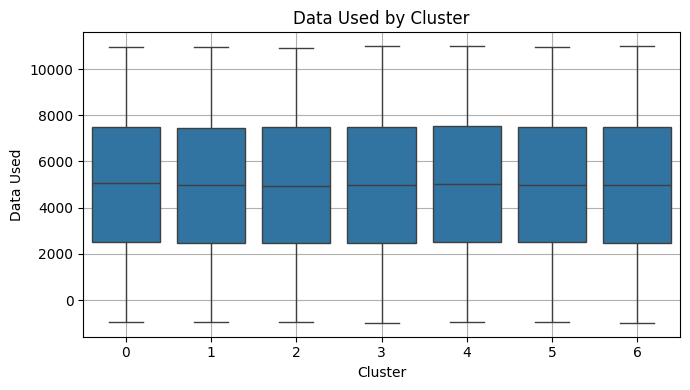

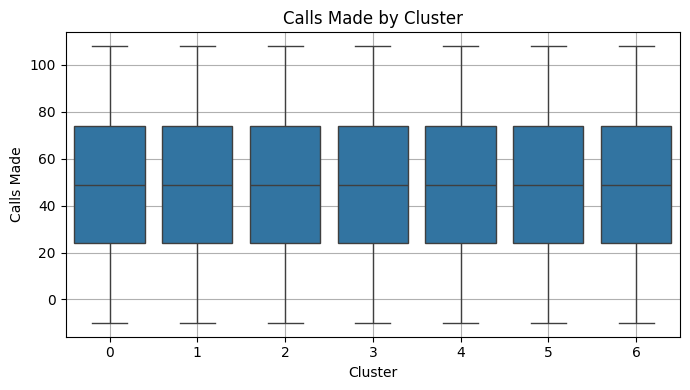

In [18]:
features = ['age', 'estimated_salary', 'data_used', 'calls_made']

for feature in features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x='cluster', y=feature, data=df_plot)
    plt.title(f"{feature.replace('_', ' ').title()} by Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(feature.replace('_', ' ').title())
    plt.grid(True)
    plt.tight_layout()
    plt.show()


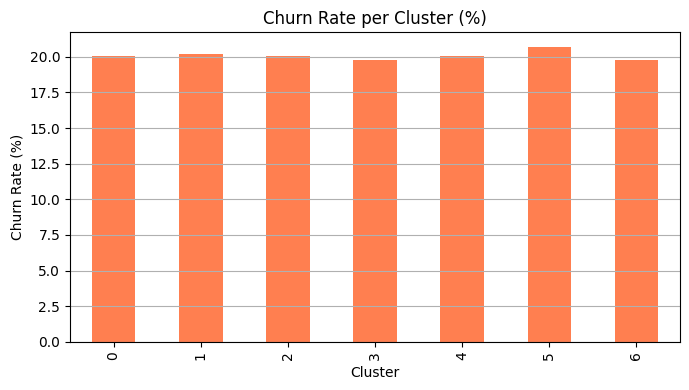

In [19]:
# Churn rate per cluster
churn_rate = df_plot.groupby('cluster')['churn'].mean() * 100

# Plot
plt.figure(figsize=(7, 4))
churn_rate.plot(kind='bar', color='coral')
plt.title("Churn Rate per Cluster (%)")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Cluster")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


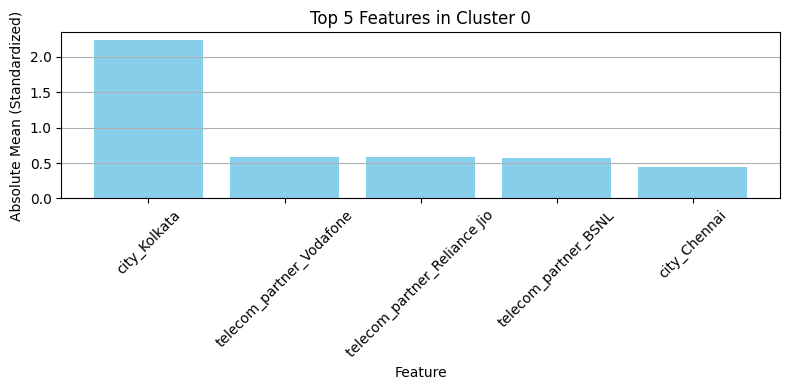

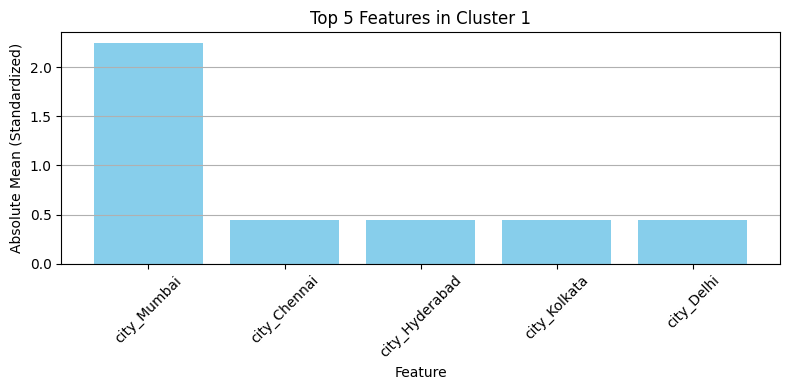

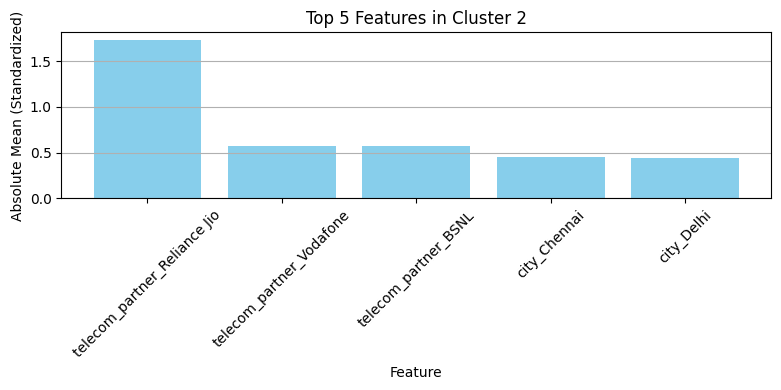

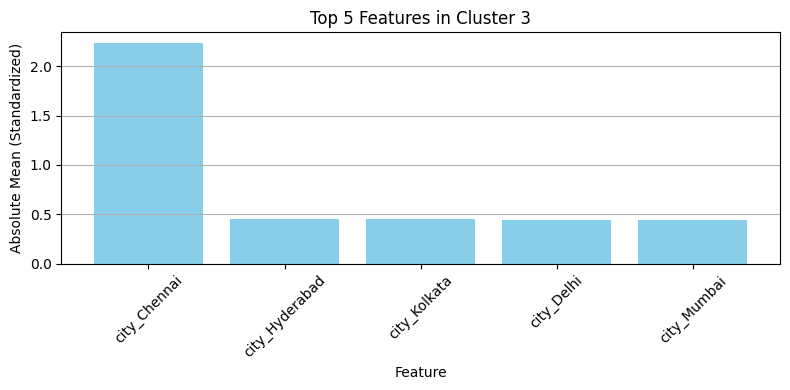

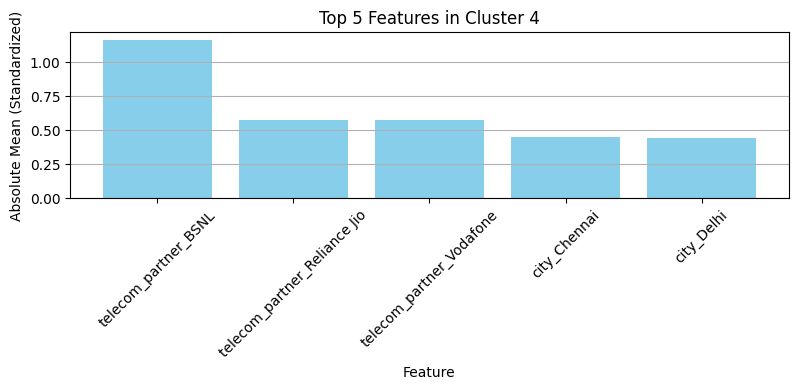

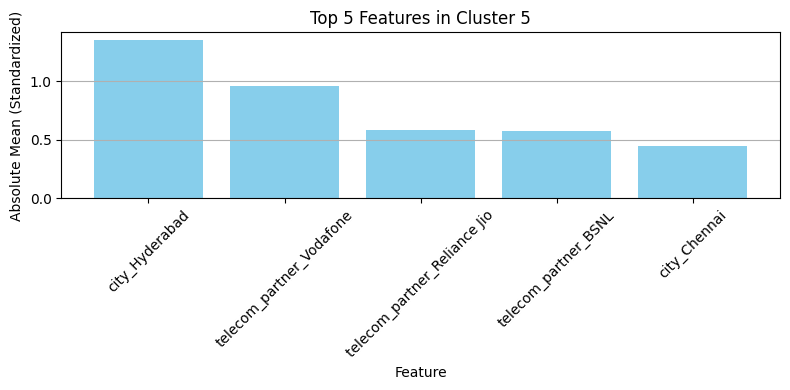

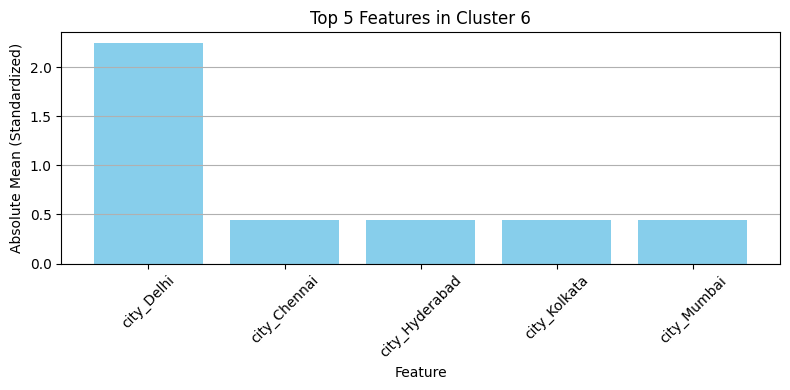

In [21]:
import matplotlib.pyplot as plt

# Loop through each cluster and plot top 5 features
for i in range(cluster_profile.shape[0]):
    cluster_vals = cluster_profile.iloc[i].abs().sort_values(ascending=False)[:5]
    features = cluster_vals.index
    scores = cluster_vals.values

    plt.figure(figsize=(8, 4))
    plt.bar(features, scores, color='skyblue')
    plt.title(f"Top 5 Features in Cluster {i}")
    plt.ylabel("Absolute Mean (Standardized)")
    plt.xlabel("Feature")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()


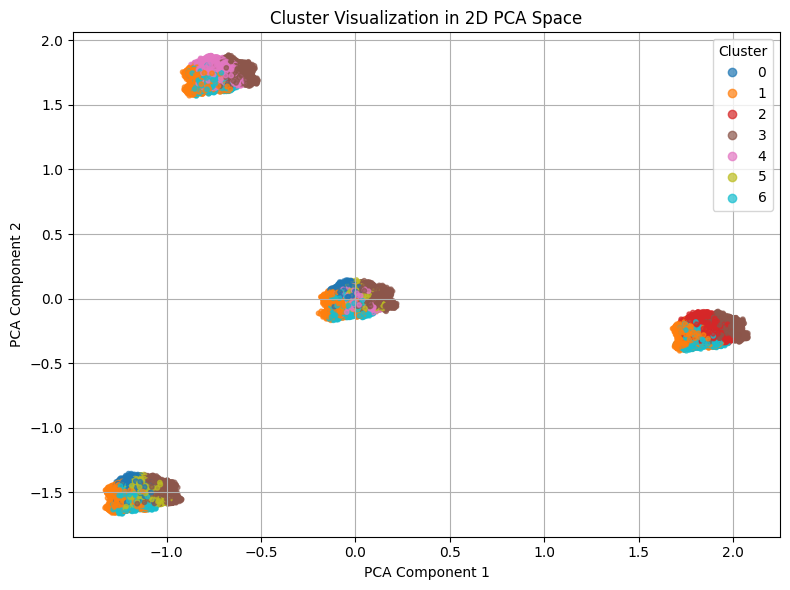

In [26]:
import matplotlib.pyplot as plt

# 2D PCA scatter plot colored by cluster
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='tab10', s=10, alpha=0.7)

# Add legend with cluster labels
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("Cluster Visualization in 2D PCA Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()
